# Notebook 02:  Bias & Fairness Analysis

This notebook performs a bias and fairness analysis to the clean dataset, after the remediation steps in the previous notebooks were done (`cleaned_dataset.json`).  

The objective is to:
- Identify potential bias in historical decisions
- Find supporting/refuting evidence of that bias  
- Perform proxy discrimination analysis
- Explore potential interaction effects 
- Provide visualizations of findings


This notebook is structured as follows:

1. Gender Bias Patterns
2. Age Bias Patterns
3. Proxy Discrimination Analysis
4. Interaction Effects 
5. Bias & Fairness Analysis Summary

## 0. Imports and loading the dataset
Before performing any analysis, it is necessary to import the necessary libraries that will auxiliate in performing tasks, such libraries include pandas and numpy. It is also to load the JSON file containing the cleaned datafram from the previous notebook.

In [44]:
# Imports and loading the dataset
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the JSON 
df = pd.read_json("../data/cleaned_dataset.json")

# Convert the DataFrame into a flat list of row dictionaries
records = df.to_dict(orient='records')

# Now flatten the nested dictionaries
df_clean = pd.json_normalize(records)

df_clean = df_clean[df_clean["dq_action"] == "ok"]
# Sanity check
print("Columns in the cleaned DataFrame:")
print(df_clean.columns.tolist())


Columns in the cleaned DataFrame:
['_id', 'spending_behavior', 'processing_timestamp', 'loan_purpose', 'notes', 'applicant_info.date_of_birth_clean', 'dq_flag_duplicate_note', 'dq_flag_duplicate_ssn', 'dq_flag_duplicate_email', 'dq_duplicate_any', 'dq_action', 'dq_flag_future_processing_ts', 'applicant_info.full_name', 'applicant_info.email', 'applicant_info.ssn', 'applicant_info.ip_address', 'applicant_info.gender', 'applicant_info.date_of_birth', 'applicant_info.zip_code', 'applicant_info.gender_clean', 'financials.annual_income', 'financials.credit_history_months', 'financials.debt_to_income', 'financials.savings_balance', 'financials.annual_salary', 'financials.annual_income_clean', 'decision.loan_approved', 'decision.rejection_reason', 'decision.interest_rate', 'decision.approved_amount']


### Assessing Gender Bias: Disparate Impact and Hypothesis Testing

We assess demographic parity and potential bias primarily through the **Disparate Impact (DI) Ratio**. The formula is:

$$DI = \frac{\text{Approval Rate of Unprivileged Group}}{\text{Approval Rate of Privileged Group}}$$

The **Four-Fifths Rule** serves as an industry-standard threshold. It states that if one group's approval rate is less than 80% ($DI < 0.8$) of the privileged group's rate, it flags potential adverse impact against the unprivileged group. This serves as a trigger to rigorously investigate for potential discrimination.



#### Statistical Testing for Disparities
To investigate the flagged disparity, we conduct a two-sample hypothesis test at a 5% significance level ($\alpha = 0.05$) to determine if the difference in approval rates (or means) is statistically significant. 

* **$H_0: \mu_1 - \mu_2 = 0$** (There is no difference between the groups' true means)
* **$H_1: \mu_1 - \mu_2 \neq 0$** (There is a statistically significant difference between the groups)

The test statistic is calculated using the sample means ($\bar{x}$), sample variances ($s^2$), and sample sizes ($n$):

$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$

*Note: For large sample sizes ($n > 30$), the t-distribution approaches the standard normal (Z) distribution, making the critical value approximately **1.96** for a two-tailed test at $\alpha = 0.05$.*

#### Conclusion Criteria
* **If $|t| > 1.96$**: We **reject the null hypothesis**. There is statistically significant evidence supporting a disparity in outcomes between the groups.
* **If $|t| \le 1.96$**: We **fail to reject the null hypothesis**. There is insufficient statistical evidence to confirm a disparity exists.

**Important Note:** It is standard practice to prioritize statistical testing if the DI flags potential bias ($DI < 0.8$). However, a $DI \ge 0.8$ does not mathematically guarantee the complete absence of discrimination; it simply means the disparity does not cross the standard regulatory threshold for *prima facie* adverse impact.

# 1.1 Loan Approval

As there is only 2 categories, we started by checking which of them was the unprivileged one. 

If one of the DI ratios is below 0.8, we will treat the group in the denominator as the unprivileged one.

In [45]:
# Getting the needed elements of the Disparate Impact Ratio (DI)
approved_by_gender = df_clean.groupby("applicant_info.gender_clean")["decision.loan_approved"]
female_approved = approved_by_gender.mean().iloc[0] 
male_approved = approved_by_gender.mean().iloc[1]

# Getting the DI
gender_DI = female_approved / male_approved if male_approved > 0 else 0
print(f"\nGender Disparate Impact Ratio (Female as unprivileged): {gender_DI:.2f}")

if gender_DI < 0.8: print("Warning: Potential bias detected against females.")
else:    print("No significant bias detected against females.")


Gender Disparate Impact Ratio (Female as unprivileged): 0.77


**From now on, we will treat "Female" as the unprivileged group.**

In [46]:
# Statistical test for gender discrimination on loan approval
# Basis for the test
means = approved_by_gender.mean()
totals = approved_by_gender.count()
std = approved_by_gender.std()

# Elements for the t-test
t_test = (means.iloc[1]-means.iloc[0]) / np.sqrt((std.iloc[0]**2 / totals.iloc[0]) + (std.iloc[1]**2 / totals.iloc[1])) if totals.iloc[0] > 0 and totals.iloc[1] > 0 else 0
crtical_value = 1.96  # for a 95% confidence level
print(f"\nT-test statistic: {t_test:.2f}")
print(f"Critical value for 95% confidence: {crtical_value:.2f}\n")

# Conclusion of the t-test
if abs(t_test) > crtical_value:
    print("H0 REJECTED: There is a statistically significant difference in loan approval rates between genders.")
else:
    print("H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in loan approval rates between genders.")


T-test statistic: 3.50
Critical value for 95% confidence: 1.96

H0 REJECTED: There is a statistically significant difference in loan approval rates between genders.


# 1.2 Interest Rate

In [47]:
# Statistical test gender discrimination on interest rates
# Basis for the test
ir_by_gender = df_clean.groupby("applicant_info.gender_clean")["decision.interest_rate"]
means = ir_by_gender.mean()
totals = ir_by_gender.count()
std = ir_by_gender.std()

# Elements for the t-test
t_test = (means.iloc[1]-means.iloc[0]) / np.sqrt((std.iloc[0]**2 / totals.iloc[0]) + (std.iloc[1]**2 / totals.iloc[1])) if totals.iloc[0] > 0 and totals.iloc[1] > 0 else 0
crtical_value = 1.96  # for a 95% confidence level
print(f"\nT-test statistic: {t_test:.2f}")
print(f"Critical value for 95% confidence: {crtical_value:.2f}\n")

# Conclusion of the t-test
if abs(t_test) > crtical_value:
    print("H0 REJECTED: There is a statistically significant difference in interest rates between genders.")
else:
    print("H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in interest rates between genders.")


T-test statistic: 0.87
Critical value for 95% confidence: 1.96

H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in interest rates between genders.


# 1.3 Approved Amount

In [48]:
# Statistical test for gender discrimination on approved loan amounts
# Basis for the test
amount_by_gender = df_clean.groupby("applicant_info.gender_clean")["decision.approved_amount"]
means = amount_by_gender.mean()
totals = amount_by_gender.count()
std = amount_by_gender.std()

# Elements for the t-test
t_test = (means.iloc[1]-means.iloc[0]) / np.sqrt((std.iloc[0]**2 / totals.iloc[0]) + (std.iloc[1]**2 / totals.iloc[1])) if totals.iloc[0] > 0 and totals.iloc[1] > 0 else 0
crtical_value = 1.96  # for a 95% confidence level
print(f"\nT-test statistic: {t_test:.2f}")
print(f"Critical value for 95% confidence: {crtical_value:.2f}\n")

# Conclusion of the t-test
if abs(t_test) > crtical_value:
    print("H0 REJECTED: There is a statistically significant difference in approved loan amounts between genders.")
else:
    print("H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in approved loan amounts between genders.")


T-test statistic: 1.12
Critical value for 95% confidence: 1.96

H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in approved loan amounts between genders.


# 1.4 Rejection Reasons

Because this is a categorical (string) field, it does not support traditional parametric tests like the t-test, as concepts such as "mean" or "standard deviation" are mathematically undefined for text labels. Instead, we employ **Frequency Distribution Analysis** to identify if specific rejection criteria are being applied disproportionately to one gender over another.

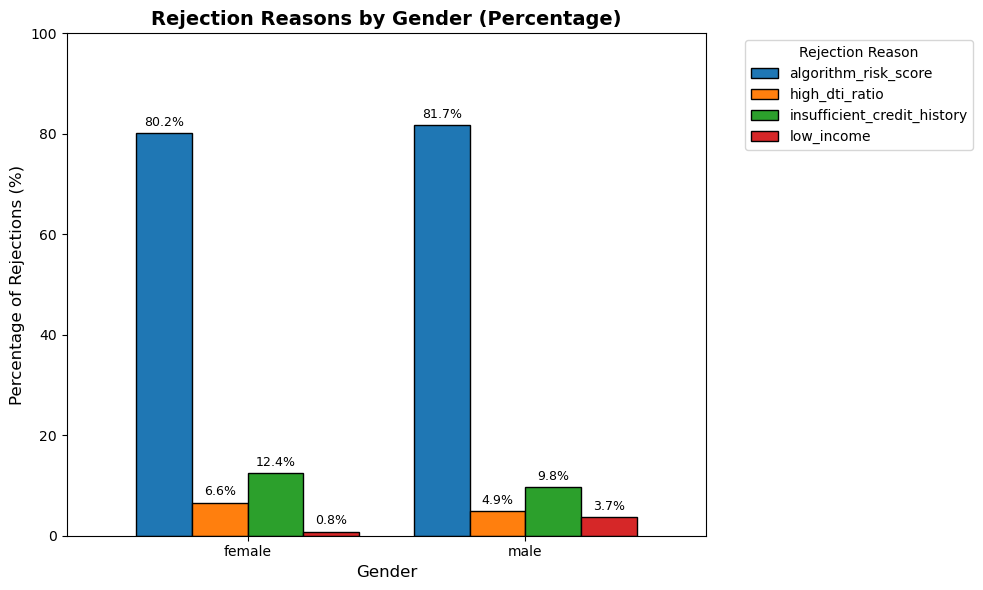

In [59]:
# Building a bar graph to show the distribution of rejection
rejection_by_gender = df_clean.groupby(["applicant_info.gender_clean","decision.rejection_reason"])["_id"].count()
plot_data = rejection_by_gender.unstack(fill_value=0)
plot_data_pct = plot_data.div(plot_data.sum(axis=1), axis=0) * 100

# Creates the bar graph
fig, ax = plt.subplots(figsize=(10, 6))
plot_data_pct.plot(kind='bar', ax=ax, edgecolor='black', width=0.8)

# Formatting the graph
ax.set_title('Rejection Reasons by Gender (Percentage)', fontsize=14, fontweight='bold')
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Percentage of Rejections (%)', fontsize=12)
ax.set_ylim(0, 100)
for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='edge', fontsize=9, padding=3)

# Adds the legend outside the plot area
ax.legend(title='Rejection Reason', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 1.5 Summary of Gender Bias Analysis

# 2. Age Bias Patterns 

This analysis was done the same way as Gender but with a slight twist, as we no longer have 2 categories of protected attributes. To get to the hypothesis testing phase, we need only 2 categories, otherwise the test won't be executed.

To reduce the number categories, I will first look at the initial age groups' averages (that were defined in periods of 12 years, through trial and error, to make all groups reasonably populated, starting from the age of 18). Detect whether there is a group that seems to have a higher/lower average than the others. And then I regroup the field, treating that "isolated" group as the privileged/unprivileged group, for the rest of the analysis.

We assess age bias patterns following the same logic as the previous analysis.

# 2.1 Loan Approval

In [50]:
# Approval Rates by Age Group
def calculate_exact_age(dob,now=pd.Timestamp.now()):

    # Convert the individual string to a datetime object
    d = pd.to_datetime(dob, errors='coerce')
    
    # If the date is missing/invalid, leave it as NaN
    if pd.isna(d):
        return float('nan')
    
    # Check if today's month and day are BEFORE the birth month and day
    hasnt_had_birthday = (now.month, now.day) < (d.month, d.day)
    
    # Subtract the years. If hasnt_had_birthday is True, it subtracts 1. If False, it subtracts 0.
    return now.year - d.year - int(hasnt_had_birthday)

# Creating the age column by applying the calculate_exact_age function to the date_of_birth column
df_clean["applicant_info.age"] = df_clean["applicant_info.date_of_birth_clean"].apply(calculate_exact_age)

# Creating age groups
df_clean["applicant_info.age_group"] = pd.cut(df_clean["applicant_info.age"], 
                                                 bins=[18, 30, 43, 55, np.inf], 
                                                 labels=["18-30", "31-43", "43-55", "55+"],
                                                 right=True)

# Calculating approval rates by age group
decisions_by_age = df_clean.groupby("applicant_info.age_group")["decision.loan_approved"]
print("\nApproval Rates by Age Group:")
print(decisions_by_age.mean())


Approval Rates by Age Group:
applicant_info.age_group
18-30    0.416667
31-43    0.630137
43-55    0.619469
55+      0.622951
Name: decision.loan_approved, dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_10876\3084900194.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decisions_by_age = df_clean.groupby("applicant_info.age_group")["decision.loan_approved"]


Analysing these means, allows us to detect that the age group between 18 and 30 has clearly lower approval rates than the others.

We first compute the DI ratio with the "18-30" group as the unprivileged one.

In [51]:
# Discrimination by Age (18-30 vs 30+)
df_clean["applicant_info.age_group"] = pd.cut(df_clean["applicant_info.age"], 
                                                 bins=[18, 30, np.inf], 
                                                 labels=["18-30", "30+"],
                                                 right=True)
approved_by_age = df_clean.groupby("applicant_info.age_group")["decision.loan_approved"]
age_DI = (approved_by_age.mean().iloc[0]) / (approved_by_age.mean().iloc[1]) if approved_by_age.mean().iloc[0] > 0 else 0

print(f"\nAge Disparate Impact Ratio (18-30 as unprivileged): {age_DI:.2f}")
if age_DI < 0.8: print("Warning: Potential bias detected against 18-30 age group.")
else:    print("No significant bias detected against 18-30 age group.")


Age Disparate Impact Ratio (18-30 as unprivileged): 0.67


C:\Users\user\AppData\Local\Temp\ipykernel_10876\3450110038.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  approved_by_age = df_clean.groupby("applicant_info.age_group")["decision.loan_approved"]


**From now on, we will treat the "18-30" group as the unprivileged one.**

In [52]:
# Statistical test for age discrimination on loan approval
# Basis for the test
means = approved_by_age.mean()
totals = approved_by_age.count()
std = approved_by_age.std()

# Elements for the t-test
t_test = (means.iloc[1]-means.iloc[0]) / np.sqrt((std.iloc[0]**2 / totals.iloc[0]) + (std.iloc[1]**2 / totals.iloc[1])) if totals.iloc[0] > 0 and totals.iloc[1] > 0 else 0
crtical_value = 1.96  # for a 95% confidence level
print(f"\nT-test statistic: {t_test:.2f}")
print(f"Critical value for 95% confidence: {crtical_value:.2f}\n")

# Conclusion of the t-test
if abs(t_test) > crtical_value:
    print("H0 REJECTED: There is a statistically significant difference in loan approval rates between age groups.")
else:
    print("H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in loan approval rates between age groups.")


T-test statistic: 3.73
Critical value for 95% confidence: 1.96

H0 REJECTED: There is a statistically significant difference in loan approval rates between age groups.


# 2.2 Interest Rate

In [53]:
# Statistical test for age discrimination on interest rates
# Basis for the test
ir_by_age = df_clean.groupby("applicant_info.age_group")["decision.interest_rate"]
means = ir_by_age.mean()
totals = ir_by_age.count()
std = ir_by_age.std()

# Elements for the t-test
t_test = (means.iloc[1]-means.iloc[0]) / np.sqrt((std.iloc[0]**2 / totals.iloc[0]) + (std.iloc[1]**2 / totals.iloc[1])) if totals.iloc[0] > 0 and totals.iloc[1] > 0 else 0
crtical_value = 1.96  # for a 95% confidence level
print(f"\nT-test statistic: {t_test:.2f}")
print(f"Critical value for 95% confidence: {crtical_value:.2f}\n")

# Conclusion of the t-test
if abs(t_test) > crtical_value:
    print("H0 REJECTED: There is a statistically significant difference in interest rates between age groups.")
else:
    print("H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in interest rates between age groups.")


T-test statistic: 0.78
Critical value for 95% confidence: 1.96

H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in interest rates between age groups.


C:\Users\user\AppData\Local\Temp\ipykernel_10876\1663110965.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ir_by_age = df_clean.groupby("applicant_info.age_group")["decision.interest_rate"]


# 2.3 Amount Approved

In [54]:
# Statistical test for age discrimination on approved loan amounts
# Basis for the test
amount_by_age = df_clean.groupby("applicant_info.age_group")["decision.approved_amount"]
means = amount_by_age.mean()
totals = amount_by_age.count()
std = amount_by_age.std()

# Elements for the t-test
t_test = (means.iloc[1]-means.iloc[0]) / np.sqrt((std.iloc[0]**2 / totals.iloc[0]) + (std.iloc[1]**2 / totals.iloc[1])) if totals.iloc[0] > 0 and totals.iloc[1] > 0 else 0
crtical_value = 1.96  # for a 95% confidence level
print(f"\nT-test statistic: {t_test:.2f}")
print(f"Critical value for 95% confidence: {crtical_value:.2f}\n")

# Conclusion of the t-test
if abs(t_test) > crtical_value:
    print("H0 REJECTED: There is a statistically significant difference in approved loan amounts between age groups.")
else:
    print("H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in approved loan amounts between age groups.")


T-test statistic: 1.71
Critical value for 95% confidence: 1.96

H0 NOT REJECTED: The t-test does not indicate a statistically significant difference in approved loan amounts between age groups.


C:\Users\user\AppData\Local\Temp\ipykernel_10876\942816360.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  amount_by_age = df_clean.groupby("applicant_info.age_group")["decision.approved_amount"]


# 2.4 Rejection Reasons

C:\Users\user\AppData\Local\Temp\ipykernel_10876\3336981433.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rejection_by_age = df_clean.groupby(["applicant_info.age_group","decision.rejection_reason"])["_id"].count()


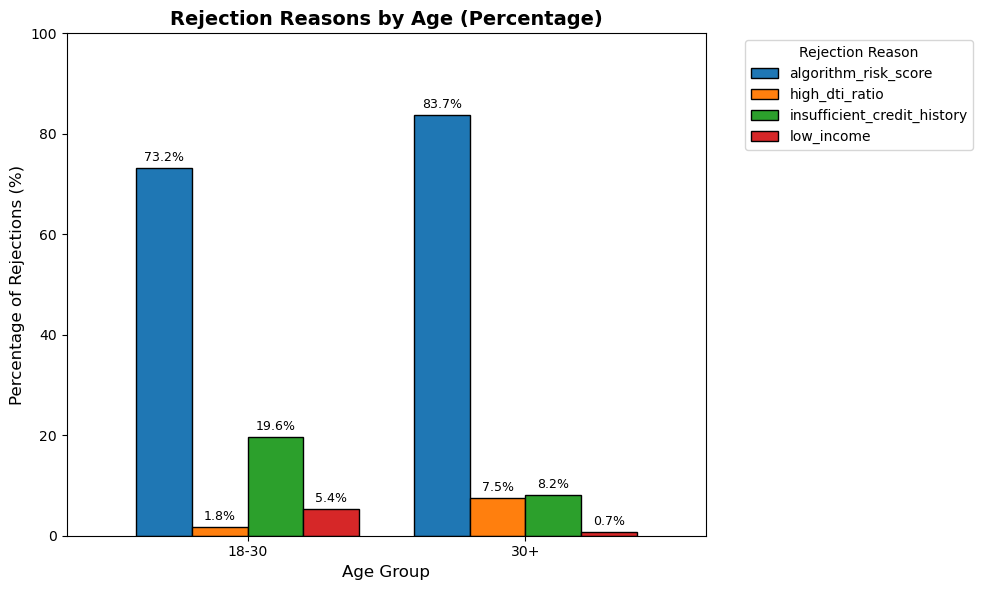

In [61]:
# Building a bar graph to show the distribution of rejection
rejection_by_age = df_clean.groupby(["applicant_info.age_group","decision.rejection_reason"])["_id"].count()
plot_data = rejection_by_age.unstack(fill_value=0)
plot_data_pct = plot_data.div(plot_data.sum(axis=1), axis=0) * 100

# Creates the bar graph
fig, ax = plt.subplots(figsize=(10, 6))
plot_data_pct.plot(kind='bar', ax=ax, edgecolor='black', width=0.8)

# Formatting the graph
ax.set_title('Rejection Reasons by Age (Percentage)', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Percentage of Rejections (%)', fontsize=12)
ax.set_ylim(0, 100)
for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='edge', fontsize=9, padding=3)

# Adds the legend outside the plot area
ax.legend(title='Rejection Reason', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 3. Proxy Discrimination Analysis

In this section, we tried to assess whether there is a variable that can act as a proxy for a protected attribute. 

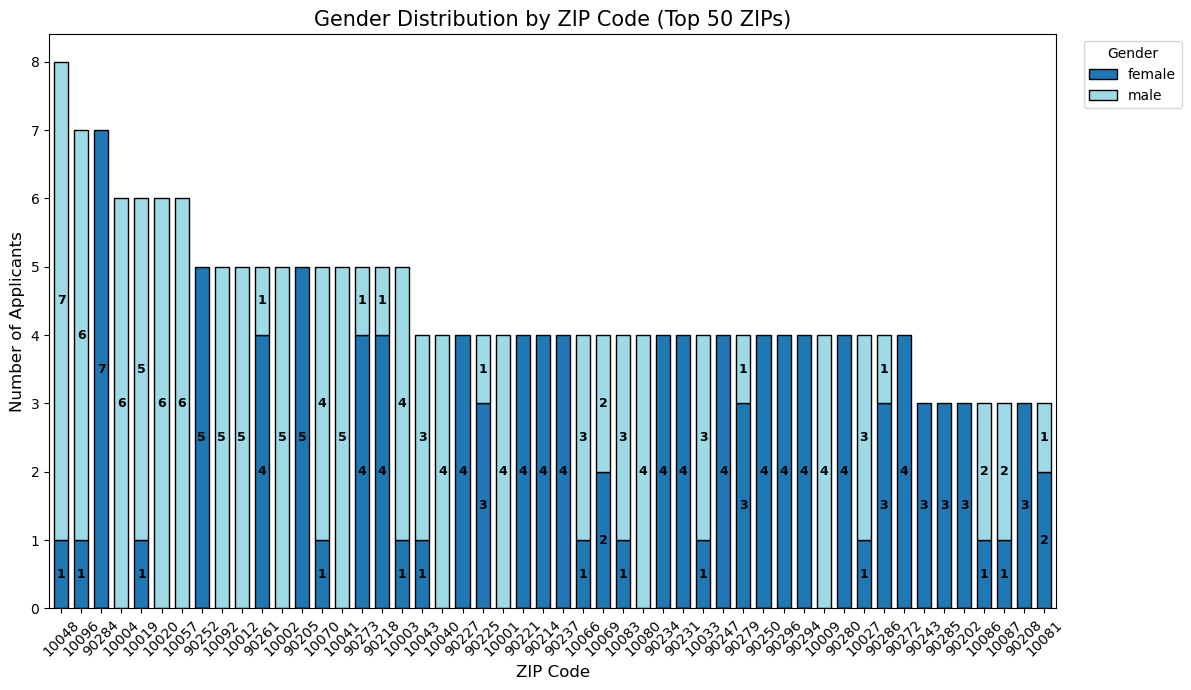

In [56]:
# ZIP Code Distribution by Gender
# Groupby, count, and UNSTACK to create columns for genders
result = df_clean.groupby(["applicant_info.zip_code", "applicant_info.gender_clean"])["_id"].count().unstack(fill_value=0)

# Grab the ZIP Codes in ascending order of total applicants
result = result.assign(Total=result.sum(axis=1)).sort_values('Total', ascending=False).drop(columns='Total').head(50)

# Build the Stacked Bar Chart
fig, ax = plt.subplots(figsize=(12, 7))
result.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', edgecolor='black', width=0.7)

# Adds the labels (raw counts)
for c in ax.containers:
    labels = [f'{int(v.get_height())}' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=9, color='black', weight='bold')

# Add Titles
ax.set_title('Gender Distribution by ZIP Code (Top 50 ZIPs)', fontsize=15)
ax.set_ylabel('Number of Applicants', fontsize=12)
ax.set_xlabel('ZIP Code', fontsize=12)
plt.xticks(rotation=45) 
ax.legend(title='Gender', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show() 

In [57]:
df_clean["applicant_info.area"] = df_clean["applicant_info.zip_code"].str[0].astype(int)
decisions_by_area = df_clean.groupby("applicant_info.area")["decision.loan_approved"]
print("\nApproval Rates by Area:")
print(decisions_by_area.mean())

df_clean["applicant_info.area"] = pd.cut(df_clean["applicant_info.area"], 
                                                 bins=[1,3, np.inf], 
                                                 labels=["1", "Others"],
                                                 right=False)
decisions_by_area = df_clean.groupby("applicant_info.area")["decision.loan_approved"]
print("\nApproval Rates by Area (after grouping):")
print(decisions_by_area.mean())

area_DI = (decisions_by_area.mean().iloc[1]) / (decisions_by_area.mean().iloc[0]) if decisions_by_area.mean().iloc[0] > 0 else 0

print(f"\nArea Disparate Impact Ratio (Others as unprivileged): {area_DI:.2f}")
if area_DI < 0.8: print("Warning: Potential bias detected against other areas.")
else:    print("No significant bias detected against other areas.")


Approval Rates by Area:
applicant_info.area
1    0.646341
3    0.555556
9    0.520000
Name: decision.loan_approved, dtype: float64

Approval Rates by Area (after grouping):
applicant_info.area
1         0.646341
Others    0.522634
Name: decision.loan_approved, dtype: float64

Area Disparate Impact Ratio (Others as unprivileged): 0.81
No significant bias detected against other areas.


C:\Users\user\AppData\Local\Temp\ipykernel_10876\3444877849.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  decisions_by_area = df_clean.groupby("applicant_info.area")["decision.loan_approved"]
